In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
from wassa_functions import allen_reconstruction_comparison
from wassa_plots import make_violin
import matplotlib.pyplot as plt

## Get statistics from real data

In [8]:
dataset_name = 'allen_data_by_image'
device = 'cpu'
dataset_path = '../../'+dataset_name+'/*'

In [9]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [10]:
saving_path = '../../wassa_copy/2025-09-30_static/results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [17]:
results_emd = allen_reconstruction_comparison(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [18]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 600,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [20]:
results_mse = allen_reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [ ]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [21]:
results_frs = allen_reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,frs=True,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [ ]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(20,9))

separation_coef = .5

for i in range(len(all_metrics)):

    reshaped = results_mse[:,i].reshape(32,100,3).swapaxes(0,2)
    results_mse_per_animal = reshaped[1]-reshaped[2]
    ax[i,0] = make_violin(ax[i,0],results_mse_per_animal,['darkolivegreen'],separation_coef=separation_coef)
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i],fontsize=20)
    ax[i,0].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,0].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,0].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_emd[:,i].reshape(32,100,3).swapaxes(0,2)
    results_emd_per_animal = reshaped[1]-reshaped[2]
    ax[i,1] = make_violin(ax[i,1],results_emd_per_animal,'blue')
    ax[i,1].set_xticks([])
    #ax[i,1].set_ylim([min(np.quantile(results_emd[:,i],.1,axis=0)), max(np.quantile(results_emd[:,i],.9,axis=0))])
    ax[i,1].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,1].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,1].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_frs[:,i].reshape(32,100,3).swapaxes(0,2)
    results_frs_per_animal = reshaped[1]-reshaped[2]
    ax[i,2] = make_violin(ax[i,2],results_frs_per_animal,'orange')
    ax[i,2].set_xticks([])
    ax[i,2].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,2].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,2].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

ax[0,0].set_title('MSE',fontsize=20)
ax[0,0].set_ylim([-4e-4,4e-4])
ax[0,1].set_title('EMD',fontsize=20)
ax[0,1].set_ylim([-4e-4,4e-4])
ax[0,2].set_title('FRS',fontsize=20)
ax[0,2].set_ylim([-.1,.1])
ax[1,1].set_ylim([-4e-2,4e-2])
ax[1,0].set_ylim([-4e-2,4e-2])
ax[1,2].set_ylim([-4e-2,4e-2])
ax[2,1].set_ylim([-4e-5,4e-5])
ax[2,0].set_ylim([-5e-4,5e-4])
ax[2,2].set_ylim([-.4,.4])
for c in range(3):
    ax[2,c].set_xlabel('animal id',fontsize=20)

fig.tight_layout()

In [ ]:
fig.savefig('../figures/results_allen_per_animal.pdf', bbox_inches = 'tight')

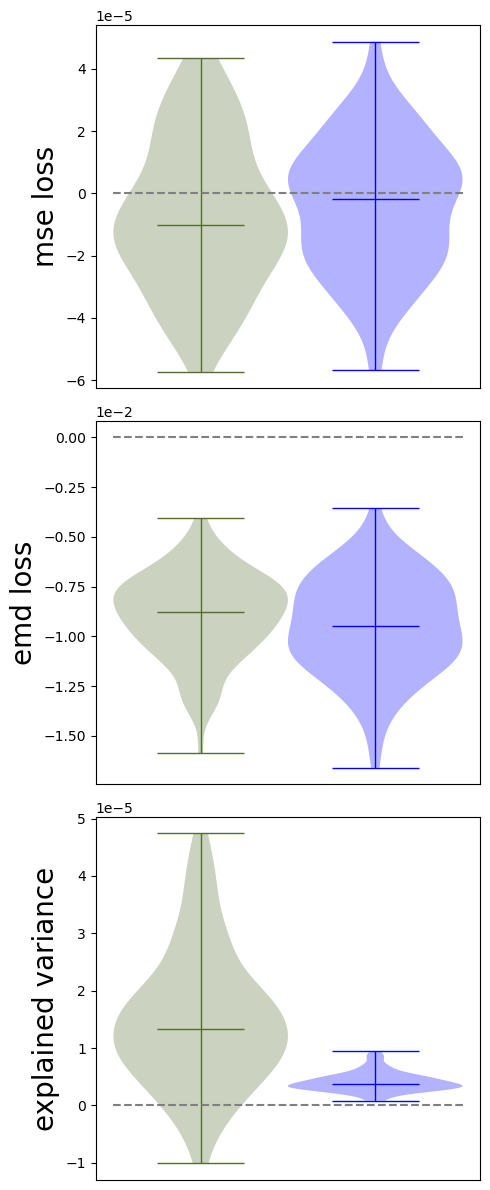

In [19]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),1,figsize=(5,12))

separation_coef = .5

for i in range(len(all_metrics)):

    reshaped = results_mse[:,i].reshape(32,100,3).swapaxes(0,2)
    results_mse_per_animal = reshaped[1]-reshaped[2]
    reshaped = results_emd[:,i].reshape(32,100,3).swapaxes(0,2)
    results_emd_per_animal = reshaped[1]-reshaped[2]
    reshaped = results_frs[:,i].reshape(32,100,3).swapaxes(0,2)
    results_frs_per_animal = reshaped[1]-reshaped[2]
    
    ax[i] = make_violin(ax[i],results_mse_per_animal.median(dim=1).values,'darkolivegreen',separation_coef=separation_coef)
    ax[i].set_xticks([])
    ax[i].set_ylabel(all_metrics[i],fontsize=20)
    ax[i].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i].hlines(0,.75,1.75,linestyles='dashed',colors='grey')
    ax[i] = make_violin(ax[i],results_emd_per_animal.median(dim=1).values,'blue',separation_coef=separation_coef,offset=1.5)
    #ax[i,2].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])
    #ax[i] = make_violin(ax[i],results_frs_per_animal.median(dim=1).values,'orange',separation_coef=separation_coef,offset=2)
    ax[i].set_xlim([.7,1.8])
fig.tight_layout()

In [154]:
fig.savefig('../figures/results_allen_per_animal_averaged.pdf', bbox_inches = 'tight')

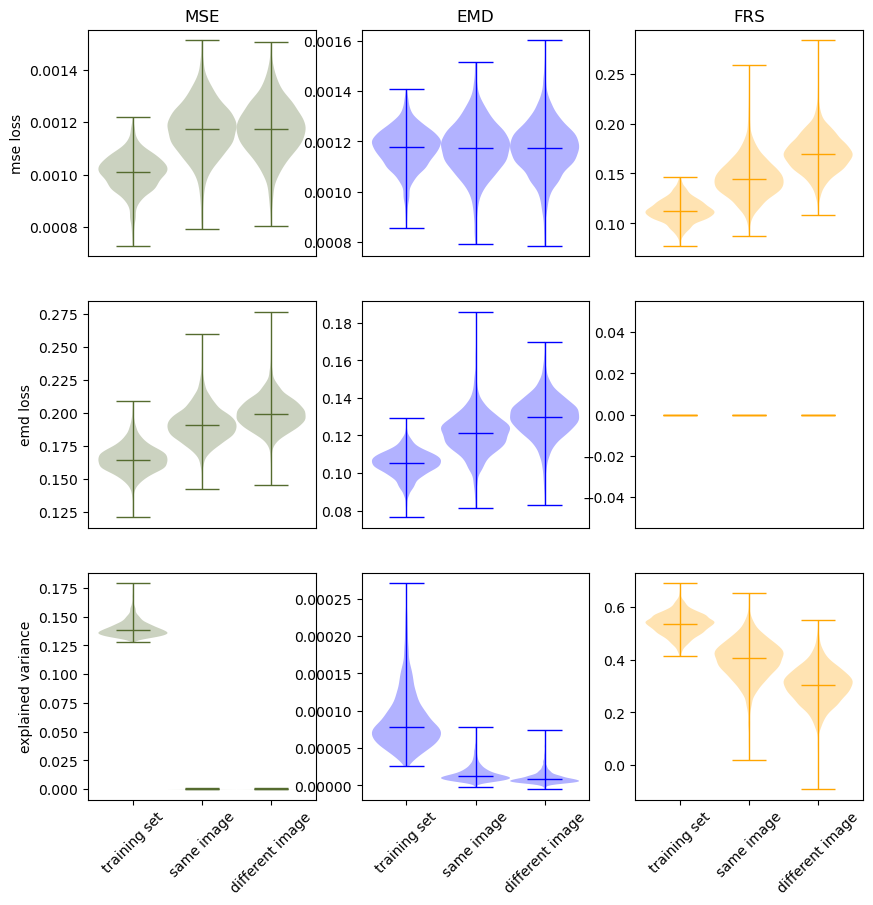

In [157]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):

    ax[i,0] = make_violin(ax[i,0],results_mse[:,i],'darkolivegreen')
    #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i])

    ax[i,1] = make_violin(ax[i,1],results_emd[:,i],'blue')
    ax[i,1].set_xticks([])
    
    ax[i,2] = make_violin(ax[i,2],results_frs[:,i],'orange')
    ax[i,2].set_xticks([])

ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[i,0].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45)
ax[i,1].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45)
ax[i,2].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45);

In [20]:
fig.savefig('../figures/results_allen_with_trainset.pdf', bbox_inches = 'tight')

Text(0.5, 1.0, 'FRS')

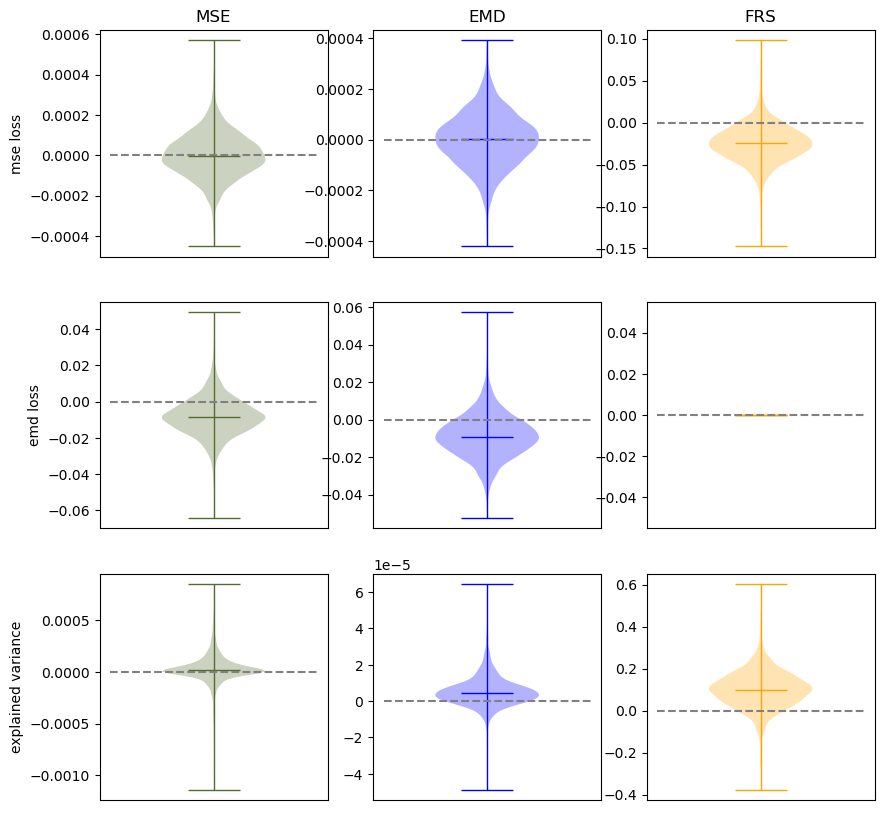

In [22]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):

    ax[i,0] = make_violin(ax[i,0],results_mse[:,i,1]-results_mse[:,i,2],'darkolivegreen')
    #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
    ax[i,0].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i])

    ax[i,1] = make_violin(ax[i,1],results_emd[:,i,1]-results_emd[:,i,2],'blue')
    ax[i,1].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,1].set_xticks([])
    
    ax[i,2] = make_violin(ax[i,2],results_frs[:,i,1]-results_frs[:,i,2],'orange')
    ax[i,2].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,2].set_xticks([])

ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')

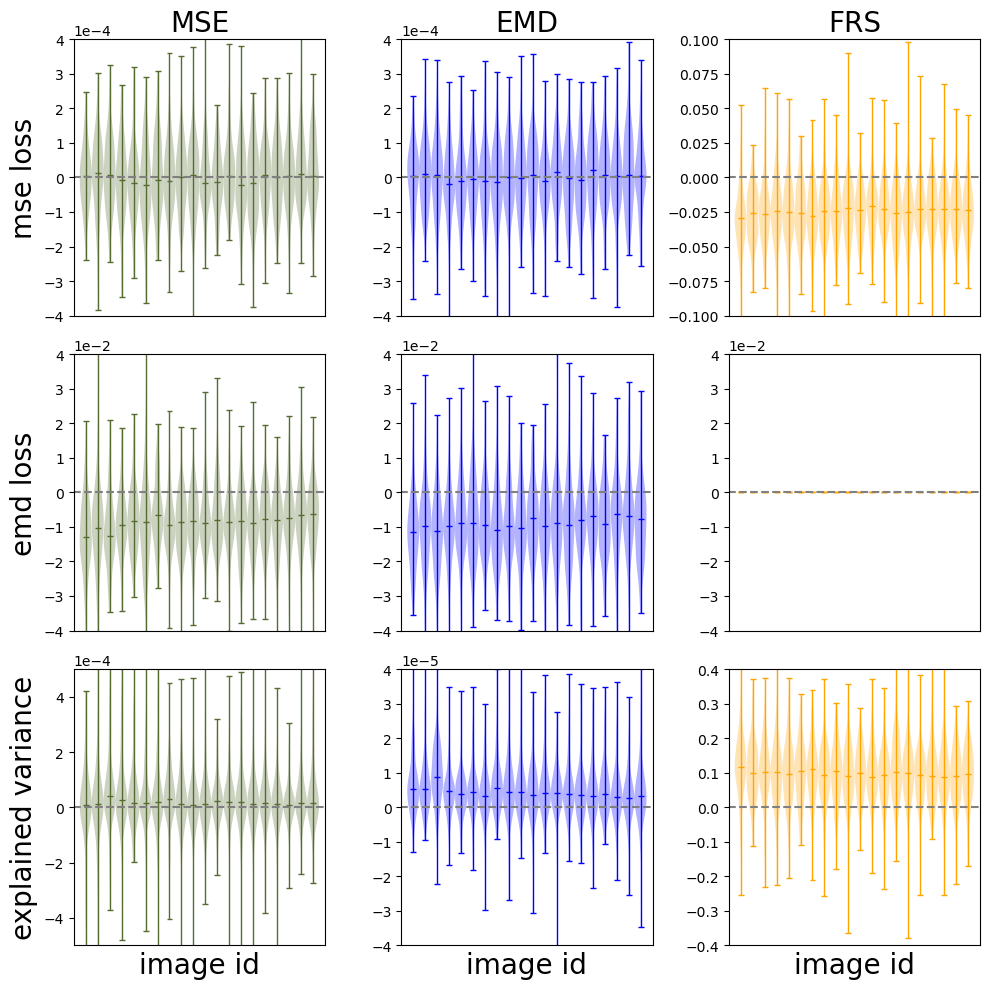

In [21]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))

for i in range(len(all_metrics)):

    reshaped = results_mse[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_mse_per_animal = reshaped[1]-reshaped[2]
    ax[i,0] = make_violin(ax[i,0],results_mse_per_animal,'darkolivegreen')
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i],fontsize=20)
    ax[i,0].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,0].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,0].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_emd[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_emd_per_animal = reshaped[1]-reshaped[2]
    ax[i,1] = make_violin(ax[i,1],results_emd_per_animal,'blue')
    ax[i,1].set_xticks([])
    #ax[i,1].set_ylim([min(np.quantile(results_emd[:,i],.1,axis=0)), max(np.quantile(results_emd[:,i],.9,axis=0))])
    ax[i,1].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,1].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,1].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_frs[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_frs_per_animal = reshaped[1]-reshaped[2]
    ax[i,2] = make_violin(ax[i,2],results_frs_per_animal,'orange')
    ax[i,2].set_xticks([])
    ax[i,2].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,2].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,2].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

ax[0,0].set_title('MSE',fontsize=20)
ax[0,0].set_ylim([-4e-4,4e-4])
ax[0,1].set_title('EMD',fontsize=20)
ax[0,1].set_ylim([-4e-4,4e-4])
ax[0,2].set_title('FRS',fontsize=20)
ax[0,2].set_ylim([-.1,.1])
ax[1,1].set_ylim([-4e-2,4e-2])
ax[1,0].set_ylim([-4e-2,4e-2])
ax[1,2].set_ylim([-4e-2,4e-2])
ax[2,1].set_ylim([-4e-5,4e-5])
ax[2,0].set_ylim([-5e-4,5e-4])
ax[2,2].set_ylim([-.4,.4])
for c in range(3):
    ax[2,c].set_xlabel('image id',fontsize=20)
#ax[i,0].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,1].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,2].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)

fig.tight_layout()

In [23]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
results_t_test = np.zeros([3,3,2])
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.ttest_ind(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2], equal_var=equal_var, alternative='two-sided')
        results_t_test[ind_training_loss,ind_metric] = t_stat, p_value
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : -0.21514617932867997 - p-value : 0.8296602213762041
For EMD training and mse loss : -0.17740798047543668 - p-value : 0.8591935635067363
For FRS training and mse loss : -51.42031874011364 - p-value : 0.0
For MSE training and emd loss : -26.37530099499268 - p-value : 1.444327733971678e-145
For EMD training and emd loss : -33.17247373197813 - p-value : 8.425496517051289e-223
For FRS training and emd loss : nan - p-value : nan
For MSE training and explained variance : 12.529943265032776 - p-value : 1.3614823257038682e-35
For EMD training and explained variance : 24.263468936904598 - p-value : 6.1415689674497194e-124
For FRS training and explained variance : 54.349426987845376 - p-value : 0.0


In [24]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
results_t_test = np.zeros([3,3,2])
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.ttest_1samp(all_results[ind_training_loss][:,ind_metric,1]-all_results[ind_training_loss][:,ind_metric,2], 0)
        results_t_test[ind_training_loss,ind_metric] = t_stat, p_value
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : -0.2888473907270609 - p-value : 0.7727168799559231
For EMD training and mse loss : -0.23959961507293911 - p-value : 0.8106560132967923
For FRS training and mse loss : -61.99542887273338 - p-value : 0.0
For MSE training and emd loss : -46.26899031690216 - p-value : 0.0
For EMD training and emd loss : -42.86258815415448 - p-value : 1.3320267e-317
For FRS training and emd loss : nan - p-value : nan
For MSE training and explained variance : 13.001000834731768 - p-value : 1.07113041371579e-37
For EMD training and explained variance : 35.59693539968734 - p-value : 4.225129714156059e-234
For FRS training and explained variance : 62.41776569393861 - p-value : 0.0


In [25]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.mood(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2],alternative='two-sided')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 2.231148733176004 - p-value : 0.025671278573958956
For EMD training and mse loss : 1.9893052128226365 - p-value : 0.04666752465938533
For FRS training and mse loss : 4.323296807717456 - p-value : 1.5371471112694218e-05
For MSE training and emd loss : 7.26996777766647 - p-value : 3.595732596551511e-13
For EMD training and emd loss : -1.639277619431362 - p-value : 0.1011554548912559
For FRS training and emd loss : 0.0 - p-value : 1.0
For MSE training and explained variance : 0.9869638849817012 - p-value : 0.32366034366325935
For EMD training and explained variance : -3.4667442861102136 - p-value : 0.0005268027976858486
For FRS training and explained variance : 4.662015499547449 - p-value : 3.1312760155852607e-06


In [26]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.mannwhitneyu(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2],alternative='two-sided')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 5082033.0 - p-value : 0.6074553597636614
For EMD training and mse loss : 5099886.0 - p-value : 0.7855085922957478
For FRS training and mse loss : 1779045.0 - p-value : 0.0
For MSE training and emd loss : 3168894.5 - p-value : 1.3846768346056038e-153
For EMD training and emd loss : 2743325.0 - p-value : 6.8695435707710645e-227
For FRS training and emd loss : 5120000.0 - p-value : 1.0
For MSE training and explained variance : 6241305.5 - p-value : 5.4262281989239016e-52
For EMD training and explained variance : 7100242.5 - p-value : 3.797672925940169e-158
For FRS training and explained variance : 8587823.0 - p-value : 0.0


In [27]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2]
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2]
        t_stat, p_value = scipy.stats.wilcoxon(err_A, err_B,alternative='greater')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 2593890.0 - p-value : 0.2533433564425043
For EMD training and mse loss : 2561863.5 - p-value : 0.49188326297474544
For FRS training and mse loss : 4837518.0 - p-value : 0.0
For MSE training and emd loss : 4521079.5 - p-value : 3.908693355065136e-308
For EMD training and emd loss : 4430794.5 - p-value : 1.257448703886427e-280
For FRS training and emd loss : 0.0 - p-value : nan
For MSE training and explained variance : 3395366.5 - p-value : 4.997862100719731e-59
For EMD training and explained variance : 4324070.5 - p-value : 5.753862625305304e-256
For FRS training and explained variance : 4842565.0 - p-value : 0.0


/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [28]:
err_A, err_B = all_results[0][:,2,1],all_results[0][:,2,2]

In [29]:
%ls 

activation_function.ipynb                   results_jitter.ipynb
adamw_eg.py                                 results_num_patterns.ipynb
allendataset_results_traintest_conv.ipynb   results_num_samples.ipynb
allendataset_results_traintest.ipynb        results_warping.ipynb
allendataset_results_whole_dataset.ipynb    training_model.ipynb
allendataset_training_synthetic_data.ipynb  training_monitoring.ipynb
dataset_generation.py                       wassa_allen.py
figure_time_diff.ipynb                      wassa_functions.py
generation_synthetic_datasets.ipynb         wassa_metrics.py
Makefile                                    wassa_plots.py
__pycache__/                                wassa.py
results/                                    wassa_training.py
results_background_noise.ipynb              wassa_utils.py
results_dropout.ipynb


In [30]:
np.save('cd .err_a.npy',err_A)
np.save('err_b.npy',err_B)

In [31]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_datasets = ['training set', 'testing set', 'other set']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        for ind_set in range(3):
            t_stat, p_value = scipy.stats.shapiro(all_results[ind_training_loss][:,ind_metric,ind_set])
            print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} on the {all_datasets[ind_set]}: {t_stat} - p-value : {p_value}')

For MSE training and mse loss on the training set: 0.9865499663454 - p-value : 7.029859670100105e-17
For MSE training and mse loss on the testing set: 0.9962776304185169 - p-value : 3.867019801667157e-07
For MSE training and mse loss on the other set: 0.9943947138398617 - p-value : 9.82849681836736e-10
For EMD training and mse loss on the training set: 0.9876326326919348 - p-value : 4.2355432966921964e-16
For EMD training and mse loss on the testing set: 0.9962683301426702 - p-value : 3.741008276037123e-07
For EMD training and mse loss on the other set: 0.9965679604889283 - p-value : 1.1118741954003478e-06
For FRS training and mse loss on the training set: 0.997876081354905 - p-value : 0.00024073558503059453
For FRS training and mse loss on the testing set: 0.9837384716889261 - p-value : 1.0192244733755157e-18
For FRS training and mse loss on the other set: 0.9908985353678101 - p-value : 2.0201199424624759e-13
For MSE training and emd loss on the training set: 0.992197170150246 - p-val

/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [32]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = permutation_test(all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy())
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

NameError: name 'permutation_test' is not defined

In [ ]:
def permutation_test(a, b, n_perm=10000):
    observed = np.mean(b) - np.mean(a)
    combined = np.concatenate([a, b])
    count = 0
    for _ in range(n_perm):
        np.random.shuffle(combined)
        new_a = combined[:len(a)]
        new_b = combined[len(a):]
        stat = np.mean(new_b) - np.mean(new_a)
        if abs(stat) >= abs(observed):
            count += 1
    return observed, count / n_perm

In [ ]:
def paired_permutation_test(a, b, n_perm=10000, alternative="greater"):
    d = b - a  # différence dans le sens que tu veux tester
    observed = np.mean(d)
    
    perm_stats = []
    for _ in range(n_perm):
        signs = np.random.choice([1, -1], size=len(d))
        perm_stats.append(np.mean(signs * d))
    perm_stats = np.array(perm_stats)

    if alternative == "greater":
        p_value = np.mean(perm_stats >= observed)
    elif alternative == "less":
        p_value = np.mean(perm_stats <= observed)
    else:  # two-sided
        p_value = np.mean(np.abs(perm_stats) >= abs(observed))

    return observed, p_value

In [ ]:
def paired_permutation_test_median(a, b, n_perm=10000, alternative="greater"):
    d = b - a  # différence dans le sens que tu veux tester
    observed = np.median(d)
    
    perm_stats = []
    for _ in range(n_perm):
        signs = np.random.choice([1, -1], size=len(d))
        perm_stats.append(np.mean(signs * d))
    perm_stats = np.array(perm_stats)

    if alternative == "greater":
        p_value = np.mean(perm_stats >= observed)
    elif alternative == "less":
        p_value = np.mean(perm_stats <= observed)
    else:  # two-sided
        p_value = np.mean(np.abs(perm_stats) >= abs(observed))

    return observed, p_value

In [ ]:
def compute_auc(a, b):
    # Proba que un élément de B soit > un élément de A
    count = 0
    total = 0
    for x in a:
        for y in b:
            if y > x:
                count += 1
            total += 1
    return count / total

In [ ]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat = compute_auc(all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy())
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat}')

In [ ]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        t_stat, p_value = paired_permutation_test(err_B,err_A)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

In [ ]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        t_stat, p_value = paired_permutation_test_median(err_B,err_A)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')